# Multimodal Transformers

Transformers can handle audio, video, images, sensor data, etc/

ViT - Vision Transformer - encoder-only, treats image patches like word tokens

DALL-E - Multimodal, generate image from text (my first AI use!)

## Vision Transformers

### RNNs w/ Visual Attention

- First use of attention beyond NLP was to make image captions
- encoder CNN processes image, outputs feature maps
- decoder RNN (w/ Attention) generates caption

Decoder uses attention to focus on the right parts of the image

Attention is great because you can actually see what the neural net "looks" at - helps a lot with explainability. You can also sometimes tell why a model makes a mistake - ie classifying a dog as a wolf when theres a lot of snow around.

### DETR: CNN-Transformer Combo for Object Detecting

- First: CNN process img inputs, outputs feature maps
- Feature maps turned into token sequence
- Token sequence goes into encoder-decoder transformer
- Bbox predictions from transformer

### The Original ViT
Idea: chop image into 16x16 patches and treat them like word tokens

- 16x16x3 (color channels) = 768-dimensional vectors per patch
- Each vector goes thru a linear layer that projects to the embedding time
- Then just treat them like word embeddings: add pos embeds, etc

Side note on inductive biases:
- Linear models assume the data is linear 
- CNNs assume patterns in one location can be useful in any location
- RNNs assume ordered inputs, most recent token matter more
- These biases mean models learn faster if they are correct, but hurt if they are wrong

#### ViT in PyTorch

In [18]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size=16):
        super().__init__()
        self.conv2d = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, X):
        X = self.conv2d(X) # shape [batch, channels, height, width]
        X = X.flatten(start_dim=2) # shape [batch, channels, h*w]
        return X.transpose(1,2)

In [19]:
class ViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=1000, embed_dim=768, depth=12, num_heads=12, ff_dim=3072, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, embed_dim, patch_size)
        cls_init = torch.randn(1,1,embed_dim)*.02
        self.cls_token = nn.Parameter(cls_init) # Class token w/ trainable embedding
        num_patches = (img_size//patch_size)**2
        pos_init = torch.randn(1, num_patches+1, embed_dim)*.02 # random normal dist
        self.pos_embed = nn.Parameter(pos_init) 
        self.dropout = nn.Dropout(p=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = embed_dim, nhead=num_heads, dim_feedforward=ff_dim, dropout=dropout,
            activation="gelu", batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.output = nn.Linear(embed_dim, num_classes)

    def forward(self, X):
        Z = self.patch_embed(X) # [batch, n_patch_tokens = l , embed] -> makes patch tokens
        cls_expd = self.cls_token.expand(Z.shape[0], -1, -1) # [batch, 1, embed] 
        Z = torch.cat((cls_expd, Z), dim=1) # [b, l+1, e] # now each patch token batch starts with the class token
        Z = Z+self.pos_embed
        Z = self.dropout(Z)
        Z = self.encoder(Z)# [b, l+1, e]
        Z = self.layer_norm(Z[:,0]) # [b, e] -> keep only class token output
        logits = self.output(Z) # batch, class
        return logits

Why do we even need a class token?
- How do we get a vector out of transformer that produces a sequence?
- After encoder runs, we have [b, l+1, e] = one embedding in each patch
- We could combine patch outputs, or
- Use a dedicated summary token
    - Every layer self-attn lets the summary token attend to all patch tokens
    - After all the layers, this is a rich global representation
    

In [20]:
vit_model = ViT(
    img_size=224, patch_size=16, in_channels=3, num_classes=1000, embed_dim=768,
    depth=12, num_heads=12, ff_dim=3072, dropout=0.1)
batch = torch.randn(4, 3, 224, 224)
logits = vit_model(batch)  # shape [4, 1000]

#### Fine-tuning a pretrained ViT
(since you probably don't own enough compute to train your own)\



In [21]:
from datasets import load_dataset
from transformers import ViTForImageClassification, AutoImageProcessor

pets = load_dataset("timm/oxford-iiit-pet")
model_id = "google/vit-base-patch16-224-in21k"
vit_model = ViTForImageClassification.from_pretrained(model_id, num_labels=37)
vit_processor = AutoImageProcessor.from_pretrained(model_id, use_fast=True)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 11584.37it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


This ViT was trained on ImageNet-21k, 14mil images on 21,800 classes. The ViTForImageClassification automatically puts in a new classificaton head.

The ImageProcessor sets the images the way the model expects: 224x244 scale, pixel vals -1 to 1, channel dim in front of space dim

In [22]:
# turn batch of imgs into tensors
def vit_collate_fn(batch):
    images = [example["image"] for example in batch]
    labels = [example["label"] for example in batch]
    inputs = vit_processor(images, return_tensors="pt", do_convert_rgb=True) #some imgs are RGBA, a for transparency, so need to force RGB
    inputs["labels"] = torch.tensor(labels)
    return inputs

In [23]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    "my_pets_vit",
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    num_train_epochs=1, # increase to actually train
    remove_unused_columns=False
)
trainer = Trainer(model=vit_model, args=args, data_collator=vit_collate_fn, train_dataset=pets["train"], eval_dataset=pets["test"])

In [24]:
# trainer.train()

### Data-Efficient Img Transformer (DeiT)

Uses distillation to transfer knowledge from teacher to student model
- Frozen, SOTA CNN as teacher model
- Add distillation token to student ViT, which is trainable (like the cls token ^^^)
- Give this new distillation tkn its own classification head (which is trained as a soft target)
- Drop both tkn and new class head for inference 

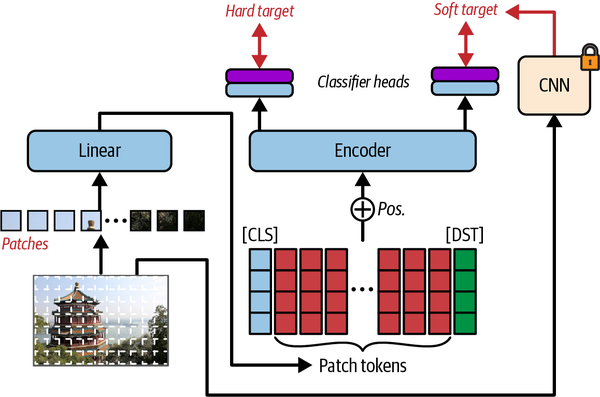

### Pyramid Vision Transformer for Dense Prediction (PVT)

Everything above was for classification, but prediction needs finer grain resolution
- Pyramid architecture: image processed into smaller but deeper image (like a CNN)
- Ex: 256x192x3 --> Patch embedding + positional embed + encoder --> 64 x 48 x 64 --> until 8x6x512

The encoder outputs a sequence of vectors, which is reshaped into a vector grid, which gets treated like an image with many channels and passed on

- Each patch might be something like 4x4, and get a 64-dim embed
- Much smaller patches for better resolution
- But Multi-Head-Attention has quadratic complexity, so you need a new attention:

**Spatial Reduction Attention** (SRA): MHA but keys+values are spatially reduced, usually by a strided convolutional layer, then layer norm

For the pyramid: 3072 patch tokens, in regular MHA, each token attends to every other, so 3072^2 attention scores. For SRA, query still uses 3072 tokens, but keys/values reduced by a factor of 8 horizontally and vertically (the factor is shrunk as the pyramid goes up). So instead of a 64x48 grid you look at an 8x6 grid, and you only need 3072 x 48 attn scores. Doesn't shrink the encoder output at all since the query is unchanged

Generally, use a FCN approach for sematic segmentation: upscale and combine the feature maps output by PVT, and a classification head that outputs 1 class per pixel


### The Swin Transformer: Faster/More Versatile ViT

- Similar hierarchical structure, but uses Window-Based Multi-head self-attn: each patch only attends to patches within the same window

Example:
- Chop img into 28x28 patch grid, then make windows out of 7x7 patch blocks for a 4x4 "window" grid on top
- So each token only attends to a 7x7 grid of tokens
- Now attention scales linearly with image size!

Swin: shifted window. If you use the same windows at every encoder, each token only ever sees info from tokens in its window. So shift the windows each layer, down 3 patches.

But wait, now you have a 5x5 grid of windows instead of a 4x4 grid, and some weird half windows at the edges: so you have wrap the image to keep the same original windows:
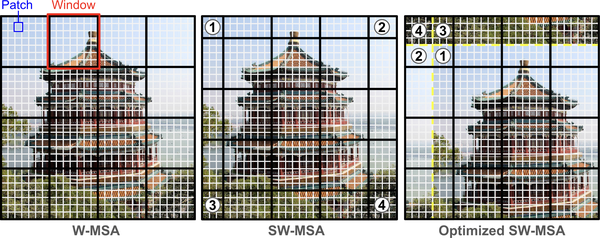

This requires careful attention masks: you dont want opposite sides of the image to see each other. This makes implementation more difficult.

Classification: ViT, DeiT

Prediction: PVT, Swin

### DINO: Self-Supervised Visual Representation Learning

For generating good image representations - used in classification, other tasks

- First: duplicate the model turning training, one teacher and one student
- Gradient descent on student, exponential moving avg of student's weights for the teacher (*momentum teacher*)
- The student is trained to match the teacher's predictions: *self-distillation*
- At every step, input images get augmented with color jitter, greyscale, blur, flipping, etc
- IMPORTANT: Teacher gets the full image, lightly augmented, student gets cropped image, heavily augmented
- Forces the student+teacher to agree on high level representations

But what if the model just learns to ignore the input and output the same thing no matter what? 
- Keep moving average of predicted logits, subtract from predicted logits
- This is *centering*: forces roughly equal distribution of class predictions

Okay, so what if the model just predicts p = 1/n_classes for each class?
- *Sharpening*: force the model to have high confidence in its highest predictions with a low temperature

After training, keep the student. It will predict a sequence of patch embeddings, and you could train a classifier on top of the class token output embedding.

If you need a classifier but have no labels, DINO is a good chocie

### Other Major Models + Techniques:

- **Scaling Vision Transformer**: Scale ViTs according to data: made a 2B model that got 90.4% accuracy
- **BEiT**: BERT Pretraining of Img Transformers: Remember token masking? Lets do the same thing, for images, predicting missing patches. Doesn't predict pixels themselves, predicts token IDs from an autoencoder (ch18)
- Masked Autoencoders Are Scalable Vision Learners: Masked image modeling, but uses a masked autoencoder to predict raw pixel values, and an asymmetric encoder/decoder: big encoder to process known patches, small decoder to reconstruct whole image
- Model Soups: train multiple transformers and average their weights
- **EVA**: Exploring the Limits of Masked Representation Learning. EVA is a huge ViT, with enhanced MAE
- **I-JEPA**: Yann LeCun proposed a Joint-Embedding Predictive Architecture in 2022, goal of deepening world understanding, with new models released (as recently as 2026!). I-JEPA is for images
    - JEPA involves two encoders and a predictor. Teacher encoder sees full input, student sees part of an input, predictor tries to guess the missing parts based on the student embeddings
    - Teacher is just a momentum teacher, student + predictor get gradient descent

Other areas:
    - mobileVit for small models for mobile devices
    - Hierarchical transformers for dense prediction
    - Segmentation models
    - ViTDet/RT-DETR for object detection
    - Token merging, token pruning, early exiting, patch selection

## Multimodal Transformers

Modalities are very different: some are discrete, some are continuous, and combining them is hard. Two challenges:
- Fusion: how to combine two modalities into one representation space?
- Alignment: discover relationships btwn modalities

Transformers work for basically any modality as long as you can chop it into tokens+embed

How to combine modalities after you have embeddings? Sum them, concatenate, fusion encoder, etc. What about alignment? Multi head attention finds big patterns!

### VideoBERT: BERT for Text+Video

Take pretrained BERT-large and extend the embedding matrix to allow for video tokens, and then just continue training. Used self-supervision. Dataset was a lot of instructional youtube videos, like cooking where theres usually live audio descriptions (or text captions) of what is happening in the video.

For the data:
- Visual: extract 1.5s clips at 20fps (30 frames), pass clips thru 3D CNN, uses inception + separable convolutions, add a 3D avg pooling layer to get a 1024-dim vector per clip
- Text: use youtube's text captions. forget about audio for this model

Now you have a token text sequence and a vector sequence of the video clips for these actions. But you don't have a "vocabulary" of video tokens.. so have to make one.
- Gather all 1.5s video clips, then k-neighbors cluster with k=12. Then for each cluster, cluster again, with k=12, for k=144, then keep going until you have 12^4 (20,736) clusters. Hierarchical k-means is usually better and faster, now each vector has a cluster ID!
- This is incredibly lossy, you are discretizing a continuous distribution. But VideoBERT still did well

VideoBERT used masked prediction for video-only and text-only pretraining. For video+text, concatenate with a separator token between, and the model just has to guess if the concatentation was a real or fake one (did some random concatentation which used a different text clip from the same video)

Linguistic-visual alignment is hard: what if the person in the video is describing a sequence of steps that WILL happen? Add more random neighboring sentences for extra context 

Also change video sampling rate to make model robust to action speeds (10fps, 30fps)

**Zero-shot action classification**: given some video clip, figure out the action performed. Use some test video clip and the text sequence: "Now let me show you how to [MASK] the [MASK]". Model predicts verb + noun that hopefully align to whatever the video is doing

**Video captioning**: Take an average of all of VideoBERTs final output rep's, use a heavily masked sentence with a few filler words

### ViLBERT: Dual-Stream Transformer for Text+Img

Different modalities need different amounts of processing: images coming from a deep CNN need less preprocessing than text straight from a book. 

The researchers also hypothesized: text in a sentence has stronger relationships than regions in an image

So give each modality its own encoder, and eventually connect the two through a new bidirectional cross-attention: **co-attention**

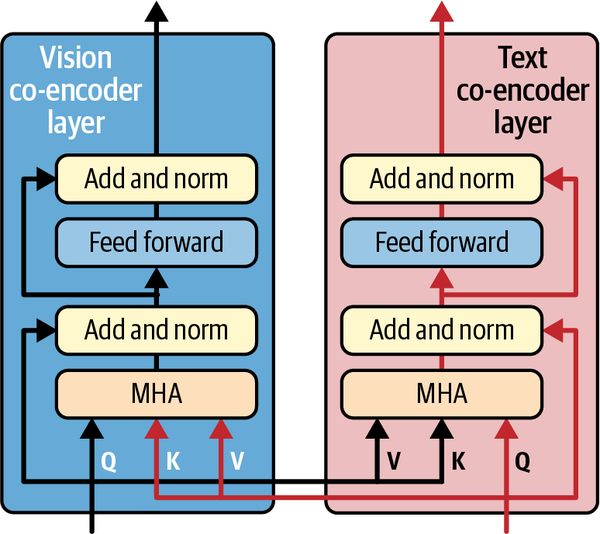

In the connected layer pairs: MHA query of one encoder used as MHA key/value for other encoder

Just add co-attn layers on top of a good text encoder(bert base) (if you are using rich image reps, the visual encoder starts at the co-attn layers)

R-CNN only looks at important region feature vectors, and outputs 10-36 vectors

Regions don't have the natural order of words - visual encoder uses spatial encodings, each regions bbox is encoded as a 5D vector: upper left, lower right, ratio of img covered by bounding box. Then this 5D vector gets linearly projected to the same dimensionality as the visual vector, and then just added to it

Then a [IMG] token gets preprended (front appended) to visual sequence, similar to class token but instead of being a trainable embedding its an average of the feature vectors (prior to spatial encoding) + spatial encoding for full bbox

There is no fixed size visual vocabulary, as there is no clustering step, so the model gets trained to predict the CNN class distribution. This is far easier than predicting raw pixels. This is used for masked token pretraining

For linguistic-visual alignment, model takes IMG / CLS outputs, computes itemwise product and passes output to binary classification head which guesses whether or not the img and text match. Why product over addition? Amplifies features strong in both representations (kinda like an AND gate)

ViLBERT was SOTA on many tasks, and massively influential due the dual-stream architecture.

### CLIP: Dual-Encoder Text+Image Model w/ Contrastive Pretraining

Contrastive learning: the model learns to encode text and image into similar vector representations when the text and image match, and dissimilar when they dont match.

This makes the model good at zero-shot img classification, give it a text string and it can identify classes in an img based on similarity

In [25]:
from transformers import pipeline
import warnings
warnings.filterwarnings("ignore")

model_id = "openai/clip-vit-base-patch32"
clip_pipeline = pipeline(task="zero-shot-image-classification", model=model_id, device_map="auto", dtype="auto")
candidate_labels = ["cricket", "ladybug", "spider"]
image_url = "https://homl.info/ladybug" 
results = clip_pipeline(image_url, candidate_labels=candidate_labels, hypothesis_template="This is a photo of a {}.")
results

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5959.46it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.9972864389419556, 'label': 'ladybug'},
 {'score': 0.0016505323583260179, 'label': 'spider'},
 {'score': 0.001063124043866992, 'label': 'cricket'}]

CLIP does not use any co-attn, just text and vision encoders. Original CLIP used GPT-2 (which is a decoder), but wasnt used for next token prediction so the final token output could be used as a whole sequence rep

On top of the vision encoder is a pooling layer so it outputs 1 vector for the img, not feature maps. Additionally, a linear layer to project to output space.

How does contrastive loss work?
1) l2 norm all vectors (now unit vectors)
2) Compute cosine similarity of img rep and text rep for all possible image-caption pairs. For a batch of size m, this gives an m x m matrix of scalars.
3) You want the main diagonal to be 1's, everything else close to 0 (2 random high-d vectors likely close to orthogonal)
4) Treat each similarity score as a class logit, just compute cross-entropy loss for each row w/ i as the target. Do the same thing for each column. Take the mean as the final loss
5) CLIP divides by a trainable temperature scalar as well

You NEED a large batch size for this: need negative and positive examples or else itll overfit to positive examples. Authors used m = 32,768

CLIP very good at general classes (cars, imagenet), not great at domain specific

CLIP also robust to perturbations, making it very good at representing images, image search based on vector similarity

In [26]:
# get text and visual featurers:
import PIL
import urllib.request
from transformers import CLIPProcessor, CLIPModel

clip_processor = CLIPProcessor.from_pretrained(model_id)
clip_model = CLIPModel.from_pretrained(model_id)
image = PIL.Image.open(urllib.request.urlopen(image_url)).convert("RGB")
captions = [f"This is a photo of a {label}." for label in candidate_labels]
inputs = clip_processor(text=captions, images=[image], return_tensors="pt",
                        padding=True)
with torch.no_grad():
    outputs = clip_model(**inputs)

text_features = outputs.text_embeds    # shape [3, 512]  # 3 captions
image_features = outputs.image_embeds  # shape [1, 512]  # 1 image (ladybug)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 52521.17it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
print(image_features @ text_features.T)
# to get probas
temperature = clip_model.logit_scale.detach().exp()
rescaled_similarities = image_features @ text_features.T * temperature
probabilities = torch.nn.functional.softmax(rescaled_similarities , dim=1)
probabilities

tensor([[0.2336, 0.3021, 0.2380]])


tensor([[0.0011, 0.9973, 0.0017]])

### DALL-E: Img From Text

Original architecture: GPT-like, predict next token, trained on many img-caption pairs. Visual tokens generated by a dVAE model which takes in an image and outputs a token sequence based on some fixed vocabulary

DALL-E 2: First, feed text to CLIP to get text embedding, then feed this to a diffusion model to guide image gen.

DALL-E 3: OpenAI was closed at this point so all we know is that it is diffusion based, doesn't use CLIP, and uses GPT to rewrite the prompt prior to image gen. Followed instructions way better and moderated input.

### Perceiver: Bridge High-Res Modalities w/ Latent Spaces

So far: every transformer has chopped inputs into tokens. Token chopping is good because you get an inductive bias of "nearby pixels/letters are more relevant" but when you have massive amounts of data then biases might hurt. More data = more chance the model figures it out own its own.

The Perceiver Architecture: 

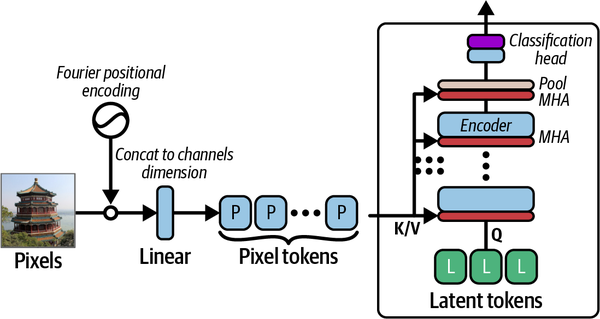

1) The image is chopped into pixels, each one is a 3D rgb vector
2) Positional encodings concatenated to RGB vectors. Both horizontal and vertical coordinates get encoded.
    - Positional encoding vector includes: x, y, sin(pi * fx), sin(pi* fy), cos(pi * fx), cos(pi * fy). This gets repeated some amount (K) times with frequency value f going from 1 to mu/2, with mu = target resolution. Dimensionality of pos encoding vector is d(2K+1), with d = input dims. If d=2, k=6, final dim is 26. Concat to Rgb, get 29-dim vector. Then you pass thru a linear layert to expand to whatever the mkdel dimension is (512)
3) Perceiver has repeated processing blocks. Each block is 1 cross-attention MHA followed by a transformer encoder (with multiple layers). Last block is 1 cross-attn MHA and average pool to turn input sequence into vector, then feed into clssification head
4) Pixel tokens fed to Perceiver through MHA layers, as keys and values. So the Perceivers attends to pixel tkns thru cross-attn only
5) Input to Perceiver is a short seq of *latent tokens*. These are like hidden states in RNNs, they get updated thru the forward pass by cross-attn.
6) Sharing weights across processing blocks also gets good results: this makes it basically a RNN

Very good at hih res. For example:
- 224x244 img has 50k pixels, 50k^2 = 2.5 billion regular attn scores for regular attn
- But we only use cross-attn, so 50k * n_latent_tokens for Perceiver

### Perceiver IO: Flexible Output for Perceiver

This allowed the Perceiver model to do stuff like predict where each pixel will move, play starcraft II, etc. Identical, but replaces pool + classification head w/ an output mechanism:
- New cross-attn layer that acts as decoder by attending to the output latent tokens
- Num output tokens is task specific:
    - For classification, 1 output vector, so one output query token
    - For MlM, 1 output token per masked token, and class head on top
    - To find masked token pos, output query tokens are learnable position embeddings
        - Ex: "The dog [MASK] the [MASK]" : use pos embed 2 as first query token, pos embed 4 as second query token
    - For optical flow: one output token per pixel

    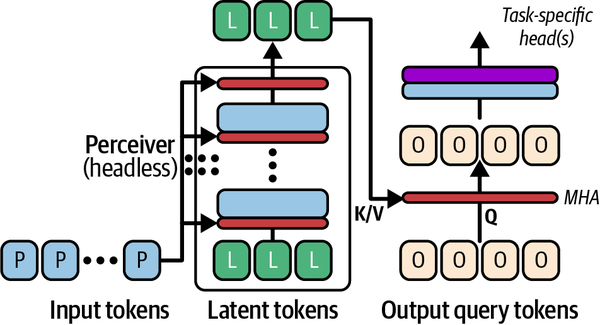

Why can we have so many output query tokens? They only attend to latent tokens!!! Most important part of perceiver

Caveat: Perceiver is bidirectional, so not good for autoregressive, predicting next token (it can, kinda, with masked tokens, but not efficiently)

Solution: Perceiver AR: an autoregressive version using the last tokens of the input as latent tokens.

### Flamingo: Open Ended Visual Dialogue

VLM: Visual-language model, takes arbitrary text or images and generates text from it.

Can easily fine tune it to do any image+text -> text or image->text task with a few examples.

Based on two pretrained models:
- Vision model
- Decoder only LM

Each input image goes into vision model, outputs go through a perceiver model called a Resampler, which outputs some sequence of latent token representations. Every image gets a fairly small latent representation

Sequences from the Resampler are used as key/values to gated x-attn-dense modules, used before every block in frozen LLM:
- Each gated xattn-dense is a masked MHA followed by FFN, with a skip connection
    - Both MHA and FFN are followed by a tanh(alpha) gate. Alpha is some learnable parameter that starts at 0, where tanh(alpha)=0, so no info flows thru at the start, meaning only skip connections matter. The model has to learn which gates to open.
- In the gated xattn-dense, each text token only attends to visual tkns from the closest image before it, every other image's visual tkns masked. Previous text tokens have information about the previous photos.

Usual [s] tokens, now theres [c] and for image chunks as well.

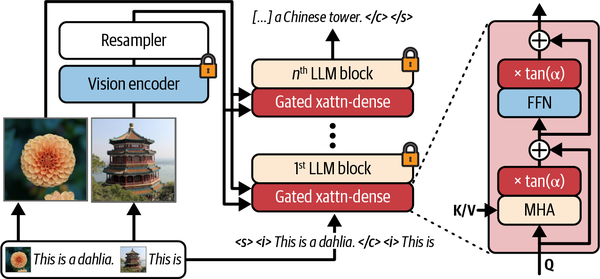

### BLIP / BLIP-2

VLM model released by Salesforce in 22

Mixture of encoder-decoder (MED) architecture. Text-only encoder, vision-only encoder, image-grounded text-encoder, image-grounded text decoder, sharing many layers.

3 objectives for training at once:
- Image text matching
- Image text contrastive (loss to align img and txt rep)
- Language modeling where the model generates caption using next token pred

Used large and clean dataset. Trained a captioning module to generate synthetic image captions, a filtering module to remove noisy data. 

BLIP: Bootstrapping language-image pretraining

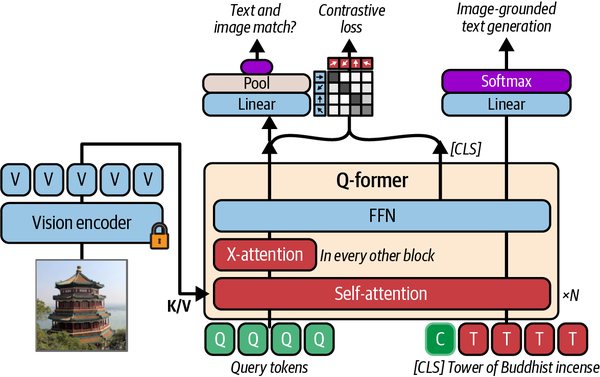

Q-Former: Querying Transformer. Same as BERT-Base, but has extra cross-attn layers in every other encoder layer, btwn self-attn and feedforward
- Takes in 3 sequences: txt tokens, visual tkns, perceiver-style latent tokens (called query tkns in BLIP 2, their outputs get used to query pretrained LLM)

For each trainable objective:
- ITM : Query tokens and text attend to each other. The outputs for the query tokens represent visual features with text context, and the text token outputs are vice versa. Query token outputs go through a linear layer that produces 2 logits per query (match, mismatch), and then BCE is applied for loss
- ITC : Query tokes and text tokens do not attend to each other. So the text and visual tokens are without each other's context. For every img/caption pair, model finds max similarity, and pushes towards +1 on the diagonal and others to 0 (like CLIP)
- LM : Text tokens are causal masked, but can see all query tokens. Query tokens see no text tokens. So query tokens are visual-only, text token outputs are img-grounded text.

Encodes images and text into the same space, but also the query tokens are helpful for next token prediction

Then: Stage 2 of training:
- Keep vision transfrmer and q-former, but drop the rest, add a new linear layer on top the q-former
- For each img/caption pair, q-former attends to vis features from the vision encoder,  output goes thru linear layer to product some visual query tokens
- The visual query tokens and text token representations get fed to the pretrained LLM
- BLIP-2 gets trained to predict the next token in the caption

Stage 2 helps the model map visual query tokens to LLM input space.

In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

device = "cuda:2"
model_id = "Salesforce/blip2-opt-2.7b"
blip2_processor = Blip2Processor.from_pretrained(model_id)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    model_id, device_map=device, dtype=torch.float16)

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"  # two cats
image = Image.open(urllib.request.urlopen(image_url))
inputs = blip2_processor(images=image, return_tensors="pt")
inputs = inputs.to(device, dtype=torch.float16)
with torch.no_grad():
    generated_ids = blip2_model.generate(**inputs)

generated_text = blip2_processor.batch_decode(generated_ids)
# or, for nice formatting
generated_text = blip2_processor.batch_decode(generated_ids,skip_special_tokens=True)

## Other Multimodal Models

- Stable Diffusion: Remarkable text-to-img model, very popular during start of AI boom
- Kosmos-1: VLM with strong visual grounding
- PaLM-E: Visual and embodied sensor data, helpful for robot control
- Qwen-VL: One of the strongest open multimodal baselines. The newer Qwen3.5 and Qwen3.6 multimodal LLMs are very very good at vision.